## **Q6: Which municipalities, school clusters, and existing SPED Centers meet combinations of the following characteristics...**

a) High learner counts or enrollment shares;  
b) High concentrations of specific disability or manifestation types;  
c) No SPED Center or ILRC within a 3-kilometer radius;  
d) High enrollment in schools hosting existing centers; and  
e) Lower municipal income class.


**Datasets used in this notebook**

| File | Role |
|---|---|
| `public_school_coordinates.parquet` / `private_school_coordinates.parquet` | School-level PSGC geography, and the authoritative source for `income_class` (per DOF DO 074-2024). |
| `sned_database_tidy_long.parquet` |  SNED learner counts by school, disability category, diagnosis type, grade, and sex. Queried through DuckDB throughout so the raw table is never loaded into pandas. |
| `sned_access_public_lgu_counts.csv` / `sned_access_pubpriv_lgu_counts.csv` | Municipality-level access roll-up, public-only vs. public+private population. |
| `sned_access_public_summary.csv` / `sned_access_pubpriv_summary.csv` | Per-school access summary — nearest facility, count within 3km, access flag |
| `sned_facility_roster.csv` | Per-school ILRC / SPED Center / SNED-implementing tags, used to build municipality- and division-level facility counts. |
| `consolidated_geodata_matched.gpkg` |Barangay-level boundary polygons for every choropleth and network map. (Caveat: NCR and BARMM areas are not cleanly organized here, potentially leading to some discrepancies) |
| `sned_access_public_pairs.csv` / `sned_access_pubpriv_pairs.csv` | Facility ↔ school 3km distance pairs, rebuilt here to the strict facility definition. |
| `SY 2025-2026 SCHOOL LEVEL DATA ON ENROLLMENT BY SCHOOL.xlsx` | Total (all-sector) enrollment per school, SY 2025-26. |

### **A. Preliminaries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import geopandas as gpd
import duckdb
import networkx as nx
import re
from IPython.display import display
pd.set_option('display.max_columns', None)

REGION_SHORT = {
    'Region I (Ilocos Region)':       'Ilocos Region',
    'Region II (Cagayan Valley)':     'Cagayan Valley',
    'Cordillera Administrative Region (CAR)': 'CAR',
    'Region III (Central Luzon)':     'Central Luzon',
    'National Capital Region (NCR)':  'NCR',
    'Region IV-A (CALABARZON)':       'CALABARZON',
    'MIMAROPA Region':                'MIMAROPA',
    'Region V (Bicol Region)':        'Bicol Region',
    'Region VI (Western Visayas)':    'Western Visayas',
    'Negros Island Region (NIR)':     'NIR',
    'Region VII (Central Visayas)':   'Central Visayas',
    'Region VIII (Eastern Visayas)':  'Eastern Visayas',
    'Region IX (Zamboanga Peninsula)':'Zamboanga Peninsula',
    'Region X (Northern Mindanao)':   'Northern Mindanao',
    'Region XI (Davao Region)':       'Davao Region',
    'Region XII (SOCCSKSARGEN)':      'SOCCSKSARGEN',
    'Region XIII (Caraga)':           'Caraga',
    'Bangsamoro Autonomous Region In Muslim Mindanao (BARMM)': 'BARMM',
}
REGION_ORDER = list(REGION_SHORT.values())

from pyfonts import set_default_font, load_google_font
regular = load_google_font("Inter")
bold    = load_google_font("Inter", weight="bold")
set_default_font(regular)

_ROOT = Path.cwd().parent
DATA  = _ROOT / "data"
EXTERNAL = DATA / "external"
PARQUET_PATH = DATA / "sned_database_tidy_long.parquet"
ENROLLMENT_PATH = DATA / "external" / "SY 2025-2026 SCHOOL LEVEL DATA ON ENROLLMENT BY SCHOOL.xlsx"

ID_LIKE_COLS = [
    'school_id', 'population_school_id', 'facility_school_id', 'beis_school_id',
    'psgc_region', 'psgc_province', 'psgc_municity', 'psgc_barangay',
    'psgc_observed_barangay', 'psgc_observed_municity',
]
PSGC_ZFILL_WIDTH = 10
PSGC_ZFILL_COLS = ['psgc_municity']

def cast_ids_to_str(df, cols=None, zfill_cols=None, zfill_width=PSGC_ZFILL_WIDTH):
    """Cast identifier-like columns to string; zero-pad psgc_municity to 10 digits.
    Applied right after every load so psgc_municity/school_id merges across files
    from different sources (csv vs parquet, int vs float) don't silently fail."""
    cols = cols or ID_LIKE_COLS
    zfill_cols = zfill_cols if zfill_cols is not None else PSGC_ZFILL_COLS
    df = df.copy()
    for c in cols:
        if c not in df.columns:
            continue
        if pd.api.types.is_float_dtype(df[c]) or pd.api.types.is_integer_dtype(df[c]):
            df[c] = df[c].astype('Int64').astype('string')
        else:
            df[c] = df[c].astype('string')
        if c in zfill_cols:
            df[c] = df[c].str.zfill(zfill_width)
    return df

def _class_rank(label):
    """Extract leading ordinal digit (1st, 2nd, ...); non-ordinal labels sort last."""
    if pd.isna(label):
        return np.inf
    m = re.match(r'\s*(\d+)', str(label))
    return int(m.group(1)) if m else np.inf

def _mode_or_first(s):
    m = s.mode()
    return m.iloc[0] if len(m) else np.nan

def _slugify(cat):
    return re.sub(r'[^a-z0-9]+', '_', str(cat).lower()).strip('_')

# ---- Core tables (same conventions as RQ4/RQ5 notebooks) ----
roster      = cast_ids_to_str(pd.read_csv(DATA / "sned_facility_roster.csv"))
pub_pairs   = cast_ids_to_str(pd.read_csv(DATA / "sned_access_public_pairs.csv"))
pp_pairs    = cast_ids_to_str(pd.read_csv(DATA / "sned_access_pubpriv_pairs.csv"))
pub_summary = cast_ids_to_str(pd.read_csv(DATA / "sned_access_public_summary.csv"))
pp_summary  = cast_ids_to_str(pd.read_csv(DATA / "sned_access_pubpriv_summary.csv"))
lgu_pub     = cast_ids_to_str(pd.read_csv(DATA / "sned_access_public_lgu_counts.csv"))
lgu_pp      = cast_ids_to_str(pd.read_csv(DATA / "sned_access_pubpriv_lgu_counts.csv"))

lgu_pub = lgu_pub.rename(columns={"n_public_schools": "n_population_schools"})
lgu_pp  = lgu_pp.rename(columns={"n_public_schools": "n_population_schools"})

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE VIEW sned_long AS SELECT * FROM read_parquet('{PARQUET_PATH.as_posix()}')")

### **A. Strict SPED facility definition**

In [2]:
# The precomputed pairs/summary files treat EVERY SNED-implementing school as a
# "facility," which understates how many schools/learners are actually without a
# real service hub nearby.
roster["is_strict_facility"] = roster.is_ilrc | roster.is_sped_center

strict_pub_pairs = pub_pairs[pub_pairs.facility_is_ilrc | pub_pairs.facility_is_sped_center].copy()
strict_pp_pairs  = pp_pairs[pp_pairs.facility_is_ilrc | pp_pairs.facility_is_sped_center].copy()
strict_roster    = roster[roster.is_strict_facility].copy()

print(f"Strict facilities (ILRC + SPED Center, deduped): {strict_roster.shape[0]:,} of {roster.shape[0]:,} roster rows")
print(f"  ILRC: {int(roster.is_ilrc.sum())}, SPED Center: {int(roster.is_sped_center.sum())}, "
      f"both: {int((roster.is_ilrc & roster.is_sped_center).sum())}")

n_strict    = ((pp_summary.n_ilrc_within_3km.astype(int) + pp_summary.n_sped_center_within_3km.astype(int)) > 0).sum()
n_inclusive = pp_summary.has_sned_access_3km.astype(bool).sum()
print(f"\nSchools (public+private) with a facility within 3km:")
print(f"  Strict (ILRC/SPED Center only):         {n_strict:,} / {len(pp_summary):,} ({n_strict/len(pp_summary):.1%})")
print(f"  Inclusive (+ SNED-implementing schools): {n_inclusive:,} / {len(pp_summary):,} ({n_inclusive/len(pp_summary):.1%})")

Strict facilities (ILRC + SPED Center, deduped): 495 of 2,629 roster rows
  ILRC: 57, SPED Center: 471, both: 33

Schools (public+private) with a facility within 3km:
  Strict (ILRC/SPED Center only):         6,461 / 54,119 (11.9%)
  Inclusive (+ SNED-implementing schools): 16,937 / 54,119 (31.3%)


In [3]:
# School-level SNED learner totals
school_disability_long = con.execute("""
    SELECT beis_school_id, School_name AS school_name, Diagnosis_Type, Category,
           SUM(Learner_Count) AS n_learners
    FROM sned_long
    WHERE Learner_Count > 0
    GROUP BY beis_school_id, School_name, Diagnosis_Type, Category
""").df()
school_disability_long = cast_ids_to_str(school_disability_long)

diag_wide = (
    school_disability_long
    .groupby(["beis_school_id", "Diagnosis_Type"], as_index=False)["n_learners"].sum()
    .pivot(index="beis_school_id", columns="Diagnosis_Type", values="n_learners")
    .fillna(0)
)
diag_wide.columns.name = None
diag_wide = diag_wide.rename(columns={
    "With Diagnosis from Licensed Medical Specialist": "n_diagnosed",
    "With Manifestations": "n_manifestation",
}).reset_index()
for col in ["n_diagnosed", "n_manifestation"]:
    if col not in diag_wide.columns:
        diag_wide[col] = 0

school_totals = diag_wide[["beis_school_id", "n_diagnosed", "n_manifestation"]].copy()
school_totals["total_learners"] = school_totals.n_diagnosed + school_totals.n_manifestation

print(f"Schools with >=1 identified SNED learner: {len(school_totals):,}")
print(f"Total identified SNED learners nationally: {school_totals.total_learners.sum():,.0f}")

# Pooled category counts per school. NOT crosswalked to diagnosed/manifestation domains
# (per your call: RQ6 doesn't need that comparison) -- all ~19 raw Category labels are
# treated as one flat nominal variable for the HHI / dominant-category calcs below.
school_category_long = (
    school_disability_long.groupby(["beis_school_id", "Category"], as_index=False)["n_learners"].sum()
)

# Program (mainstreamed/self-contained/non-graded) and grade-band (ES/JHS/SHS), per school
school_program_long = con.execute("""
    SELECT beis_school_id, Program, SUM(Learner_Count) AS n_learners
    FROM sned_long WHERE Learner_Count > 0 GROUP BY beis_school_id, Program
""").df()
school_program_long = cast_ids_to_str(school_program_long)

school_level_long = con.execute("""
    SELECT beis_school_id, School_Level, SUM(Learner_Count) AS n_learners
    FROM sned_long WHERE Learner_Count > 0 GROUP BY beis_school_id, School_Level
""").df()
school_level_long = cast_ids_to_str(school_level_long)

Schools with >=1 identified SNED learner: 38,348
Total identified SNED learners nationally: 523,939


In [4]:
# School reference table: location (psgc) + income class
pub_coords  = cast_ids_to_str(pd.read_parquet(EXTERNAL / "public_school_coordinates.parquet"))
priv_coords = cast_ids_to_str(pd.read_parquet(EXTERNAL / "private_school_coordinates.parquet"))
pub_coords["sector"]  = "Public"
priv_coords["sector"] = "Private"

REF_COLS = ["school_id", "school_name", "sector", "psgc_region_name", "psgc_province_name",
            "psgc_municity", "psgc_municity_name", "income_class", "urban_rural"]
school_ref = pd.concat([pub_coords[REF_COLS], priv_coords[REF_COLS]], ignore_index=True)

SGA_LABEL = "SGA (No Income Classification)"
MISSING_SOURCE_LABEL = "Missing (blank in source)"
UNMATCHED_LABEL = "Unmatched (failed merge)"

school_ref["is_sga_unclassified"] = school_ref["income_class"].str.contains("sga", case=False, na=False)
school_ref["income_class_display"] = np.select(
    [school_ref["is_sga_unclassified"], school_ref["income_class"].notna()],
    [SGA_LABEL, school_ref["income_class"]],
    default=MISSING_SOURCE_LABEL,
)
school_ref["income_rank"] = school_ref["income_class_display"].map(_class_rank)

HIGHER_INCOME_MAX_RANK = 3  # 1st-3rd class = "Higher income"; 4th-5th = "Lower income" (same cut as RQ5)

n_dup = school_ref.school_id.duplicated().sum()
if n_dup:
    print(f"[WARNING] {n_dup} duplicate school_id across public+private coordinates.")
print(f"school_ref: {len(school_ref):,} schools ({(school_ref.sector=='Public').sum():,} public, "
      f"{(school_ref.sector=='Private').sum():,} private)")

school_ref: 60,421 schools (48,254 public, 12,167 private)


In [5]:
def _norm_name(s):
    return (
        s.astype("string").str.strip().str.upper()
        .str.replace(r"[^\w\s]", "", regex=True)
        .str.replace(r"\s+", " ", regex=True)
    )

access_side_munis = lgu_pp[["psgc_municity", "psgc_municity_name", "psgc_province_name"]].drop_duplicates().copy()
access_side_munis["_name_key"] = _norm_name(access_side_munis["psgc_municity_name"]) + "|" + _norm_name(access_side_munis["psgc_province_name"])

coords_side_munis = school_ref[["psgc_municity", "psgc_municity_name", "psgc_province_name"]].drop_duplicates().copy()
coords_side_munis["_name_key"] = _norm_name(coords_side_munis["psgc_municity_name"]) + "|" + _norm_name(coords_side_munis["psgc_province_name"])

code_crosswalk = access_side_munis.merge(coords_side_munis, on="_name_key", how="outer", suffixes=("_access", "_coords"))

mismatched = code_crosswalk[
    code_crosswalk.psgc_municity_access.notna() & code_crosswalk.psgc_municity_coords.notna()
    & (code_crosswalk.psgc_municity_access != code_crosswalk.psgc_municity_coords)
]
unmatched_by_name = code_crosswalk[code_crosswalk.psgc_municity_access.isna() | code_crosswalk.psgc_municity_coords.isna()]

print(f"Municipalities with matching name+province but DIFFERENT codes across files: {len(mismatched)}")
display(mismatched[["psgc_municity_name_access", "psgc_province_name_access",
                     "psgc_municity_access", "psgc_municity_coords"]])

print(f"\nMunicipalities that don't even name-match at all (genuine gaps, not code drift -- inspect separately): {len(unmatched_by_name)}")
if len(unmatched_by_name):
    display(unmatched_by_name[["psgc_municity_name_access", "psgc_province_name_access",
                                "psgc_municity_name_coords", "psgc_province_name_coords"]].head(15))

# Standardize on the access-side codes, since n_population_schools, access rates,
# distances, and the whole cluster/facility pipeline are already anchored to them.
remap = mismatched.set_index("psgc_municity_coords")["psgc_municity_access"].to_dict()
school_ref["psgc_municity"] = school_ref["psgc_municity"].replace(remap)

Municipalities with matching name+province but DIFFERENT codes across files: 0


,psgc_municity_name_access,psgc_province_name_access,psgc_municity_access,psgc_municity_coords



Municipalities that don't even name-match at all (genuine gaps, not code drift -- inspect separately): 21


,psgc_municity_name_access,psgc_province_name_access,psgc_municity_name_coords,psgc_province_name_coords
646,NaN,NaN,Hadji Panglima Tahil,Sulu
671,NaN,NaN,Indanan,Sulu
701,NaN,NaN,Jolo,Sulu
722,NaN,NaN,Kalayaan,Palawan
725,NaN,NaN,Kalingalan Caluang,Sulu
849,NaN,NaN,Lugus,Sulu
863,NaN,NaN,Luuk,Sulu
907,NaN,NaN,Maimbung,Sulu
1063,NaN,NaN,Old Panamao,Sulu
1065,NaN,NaN,Omar,Sulu


### **B. Municipality master table**

In [ ]:
# Strict facility
access = pp_summary.copy()
access["n_ilrc_within_3km"] = access["n_ilrc_within_3km"].astype(int)
access["n_sped_center_within_3km"] = access["n_sped_center_within_3km"].astype(int)

access["has_ilrc_within_3km"] = access.n_ilrc_within_3km > 0
access["has_strict_facility_within_3km"] = (access.n_ilrc_within_3km + access.n_sped_center_within_3km) > 0
access["has_inclusive_facility_within_3km"] = access.has_sned_access_3km.astype(bool)  # kept for QA only

# Strict-only nearest distance: the existing nearest_facility_km mixes in SNED-implementing
# schools, so it's recomputed from the pairs table restricted to ILRC/SPED Center.
strict_nearest = (
    strict_pp_pairs.groupby("population_school_id")["road_distance_km"].min()
    .rename("nearest_strict_facility_km")
)
access = access.merge(strict_nearest, left_on="population_school_id", right_index=True, how="left")
# CAVEAT: nearest_strict_facility_km is NaN both for schools genuinely >3km from any strict
# facility AND for schools whose true nearest strict facility just falls outside the 3km.

access = access.merge(school_totals, left_on="population_school_id", right_on="beis_school_id", how="left")
access[["n_diagnosed", "n_manifestation", "total_learners"]] = access[
    ["n_diagnosed", "n_manifestation", "total_learners"]
].fillna(0)
access["is_strict_host_school"] = access.population_school_id.isin(strict_roster.school_id)

In [7]:
# Enrollment denominator (all learners, public+private)
enroll_raw = pd.read_excel(ENROLLMENT_PATH, sheet_name="DATABASE", header=5)
assert "beis_school_id" in enroll_raw.columns, "Header row offset changed -- re-check header=5"

META_COLS = ["#EMISD", "Region", "Division", "District", "beis_school_id", "School_name",
             "street_address", "Mother School ID", "school_head_name", "school_head_position_name",
             "Province", "Municipality", "Leg_district", "Barangay", "Sector",
             "School_subclassification", "School_type", "IU/NON-IU",
             "Modified Curricular Offering Classification", "Remarks"]
count_cols = [c for c in enroll_raw.columns if c not in META_COLS]

enroll = enroll_raw[enroll_raw.Sector.isin(["Public", "Private"])].copy()  # excludes SUCsLUCs/PSO
enroll["total_enrollment_all"] = enroll[count_cols].apply(pd.to_numeric, errors="coerce").fillna(0).sum(axis=1)
enroll = cast_ids_to_str(enroll[["beis_school_id", "total_enrollment_all"]])

print(f"Total public+private enrollment captured: {enroll.total_enrollment_all.sum():,.0f}")

Total public+private enrollment captured: 25,837,431


In [8]:
# Municipality master table
# a. Municipality universe + basic identifiers (public+private school count)
muni = lgu_pp[["psgc_municity", "psgc_municity_name", "psgc_province_name", "psgc_region_name",
               "n_population_schools"]].drop_duplicates(subset="psgc_municity").copy()

# b. Municipality-level income class (mode across the muni's schools -- same as RQ5)
muni_income = (
    school_ref.groupby(["psgc_municity"], as_index=False)
    .agg(income_class_display=("income_class_display", _mode_or_first))
)
muni_income["income_rank"] = muni_income["income_class_display"].map(_class_rank)
muni = muni.merge(muni_income, on="psgc_municity", how="left")

# c. Learner totals per municipality
school_totals_geo = school_totals.merge(
    school_ref[["school_id", "psgc_municity"]], left_on="beis_school_id", right_on="school_id", how="left"
)
n_unmatched_geo = school_totals_geo["psgc_municity"].isna().sum()
print(f"[QA] SNED-reporting schools with no resolvable psgc_municity: {n_unmatched_geo:,} "
      f"of {len(school_totals_geo):,} ({n_unmatched_geo/len(school_totals_geo):.1%})")

muni_learners = school_totals_geo.groupby("psgc_municity", as_index=False).agg(
    total_sned_learners=("total_learners", "sum"),
    count_diagnosed=("n_diagnosed", "sum"),
    count_manifestation=("n_manifestation", "sum"),
)
muni_learners["diagnosed_share"] = muni_learners.count_diagnosed / muni_learners.total_sned_learners.replace(0, np.nan)
muni_learners["manifestation_share"] = muni_learners.count_manifestation / muni_learners.total_sned_learners.replace(0, np.nan)
muni = muni.merge(muni_learners, on="psgc_municity", how="left")

# d. Per-category counts/shares + dominant category + HHI (pooled category set, no crosswalk)
cat_geo = school_category_long.merge(
    school_ref[["school_id", "psgc_municity"]], left_on="beis_school_id", right_on="school_id", how="left"
)
cat_wide = cat_geo.pivot_table(index="psgc_municity", columns="Category", values="n_learners",
                                aggfunc="sum", fill_value=0)
CATEGORY_SLUG_MAP = {c: _slugify(c) for c in cat_wide.columns}
cat_wide = cat_wide.rename(columns=CATEGORY_SLUG_MAP)
cat_row_total = cat_wide.sum(axis=1).replace(0, np.nan)
cat_share = cat_wide.div(cat_row_total, axis=0)

muni_categories = pd.concat([cat_wide.add_prefix("count_"), cat_share.add_prefix("share_")], axis=1)
muni_categories["dominant_category"] = cat_share.idxmax(axis=1)
muni_categories["dominant_category_share"] = cat_share.max(axis=1)
muni_categories["disability_hhi"] = (cat_share ** 2).sum(axis=1, min_count=1)
muni_categories = muni_categories.reset_index()
muni = muni.merge(muni_categories, on="psgc_municity", how="left")

print("\nCategory -> column slug (for reference):")
for orig, slug in CATEGORY_SLUG_MAP.items():
    print(f"  {orig!r:70s} -> count_{slug} / share_{slug}")

# e. Facility counts (strict definition)
fac_counts = strict_roster.groupby("psgc_municity", as_index=False).agg(
    num_ilrc=("is_ilrc", "sum"),
    num_sped_center=("is_sped_center", "sum"),
    num_sned_facilities=("school_id", "nunique"),
)
muni = muni.merge(fac_counts, on="psgc_municity", how="left")
for c in ["num_ilrc", "num_sped_center", "num_sned_facilities"]:
    muni[c] = muni[c].fillna(0).astype(int)

# 6f. Access variables (strict definition; population = all public+private schools in pp_summary)
muni_access = access.groupby("psgc_municity", as_index=False).agg(
    share_schools_without_access_to_facility=("has_strict_facility_within_3km", lambda s: 1 - s.mean()),
    mean_nearest_facility_distance_km=("nearest_strict_facility_km", "mean"),
    median_nearest_facility_distance_km=("nearest_strict_facility_km", "median"),
)
served_learners = access[access.has_strict_facility_within_3km].groupby("psgc_municity")["total_learners"].sum()
all_learners_muni = access.groupby("psgc_municity")["total_learners"].sum()
learner_access_rate = (served_learners / all_learners_muni.replace(0, np.nan)).rename("learner_access_rate")
muni_access = muni_access.merge(learner_access_rate.reset_index(), on="psgc_municity", how="left")
muni_access["share_learners_without_access_to_facility"] = 1 - muni_access["learner_access_rate"]

muni_access = muni_access.merge(
    access.groupby("psgc_municity")["has_ilrc_within_3km"].any().rename("has_ilrc_within_3km").reset_index(),
    on="psgc_municity", how="left",
)
muni_access = muni_access.merge(
    access.groupby("psgc_municity")["has_strict_facility_within_3km"].any().rename("has_any_facility_within_3km").reset_index(),
    on="psgc_municity", how="left",
)
muni = muni.merge(muni_access, on="psgc_municity", how="left")

# 6g. Host-school figures
host_learners = (
    access[access.is_strict_host_school].groupby("psgc_municity")["total_learners"].sum()
    .rename("sned_learners_in_host_schools")
)
muni = muni.merge(host_learners.reset_index(), on="psgc_municity", how="left")
muni["sned_learners_in_host_schools"] = muni["sned_learners_in_host_schools"].fillna(0)
muni["share_sned_learners_in_host_schools"] = muni.sned_learners_in_host_schools / muni.total_sned_learners.replace(0, np.nan)
muni["sned_learners_per_host_school"] = muni.sned_learners_in_host_schools / muni.num_sned_facilities.replace(0, np.nan)

# 6h. Enrollment denominator + prevalence
enroll_geo = enroll.merge(school_ref[["school_id", "psgc_municity"]], left_on="beis_school_id", right_on="school_id", how="left")
muni_enroll = enroll_geo.groupby("psgc_municity", as_index=False)["total_enrollment_all"].sum()
muni = muni.merge(muni_enroll, on="psgc_municity", how="left")
muni["sned_prevalence_rate_per_1000"] = muni.total_sned_learners / muni.total_enrollment_all.replace(0, np.nan) * 1000
muni["facilities_per_100_schools"] = muni.num_sned_facilities / muni.n_population_schools.replace(0, np.nan) * 100

# 6i. Program-intensity mix (kept per your instruction)
prog_geo = school_program_long.merge(school_ref[["school_id", "psgc_municity"]], left_on="beis_school_id", right_on="school_id", how="left")
prog_wide = prog_geo.pivot_table(index="psgc_municity", columns="Program", values="n_learners", aggfunc="sum", fill_value=0)
prog_share = prog_wide.div(prog_wide.sum(axis=1).replace(0, np.nan), axis=0).rename(columns={
    "Mainstreamed": "share_mainstreamed", "Self-contained": "share_self_contained",
    "Non-Graded": "share_non_graded", "N/A": "share_program_na",
}).reset_index()
muni = muni.merge(prog_share, on="psgc_municity", how="left")

# Grade-band mix (ES/JHS/SHS) -- kept; transition-dropoff ratio dropped per your instruction
level_geo = school_level_long.merge(school_ref[["school_id", "psgc_municity"]], left_on="beis_school_id", right_on="school_id", how="left")
level_wide = level_geo.pivot_table(index="psgc_municity", columns="School_Level", values="n_learners", aggfunc="sum", fill_value=0)
level_share = level_wide.div(level_wide.sum(axis=1).replace(0, np.nan), axis=0).rename(columns={
    "Elementary": "share_ES", "Junior High School": "share_JHS", "Senior High School": "share_SHS",
}).reset_index()
muni = muni.merge(level_share, on="psgc_municity", how="left")

print(f"\nMunicipality master table: {muni.shape[0]:,} rows, {muni.shape[1]} columns")
muni.head()

[QA] SNED-reporting schools with no resolvable psgc_municity: 246 of 38,348 (0.6%)

Category -> column slug (for reference):
  'Autism Spectrum Disorder'                                             -> count_autism_spectrum_disorder / share_autism_spectrum_disorder
  'Cerebral Palsy'                                                       -> count_cerebral_palsy / share_cerebral_palsy
  'Difficulty in Applying Adaptive Skills'                               -> count_difficulty_in_applying_adaptive_skills / share_difficulty_in_applying_adaptive_skills
  'Difficulty in Applying Knowledge'                                     -> count_difficulty_in_applying_knowledge / share_difficulty_in_applying_knowledge
  'Difficulty in Communicating'                                          -> count_difficulty_in_communicating / share_difficulty_in_communicating
  'Difficulty in Displaying Inter-Personal Behavior'                     -> count_difficulty_in_displaying_inter_personal_behavior / share_diffic

,psgc_municity,psgc_municity_name,psgc_province_name,psgc_region_name,n_population_schools,income_class_display,income_rank,total_sned_learners,count_diagnosed,count_manifestation,diagnosed_share,manifestation_share,count_autism_spectrum_disorder,count_cerebral_palsy,count_difficulty_in_applying_adaptive_skills,count_difficulty_in_applying_knowledge,count_difficulty_in_communicating,count_difficulty_in_displaying_inter_personal_behavior,count_difficulty_in_hearing,count_difficulty_in_mobility_walking_climbing_and_grasping,count_difficulty_in_remembering_concentrating_paying_attention_and_understanding,count_difficulty_in_seeing,count_emotional_behavioral_disorder,count_hearing_impairment,count_intellectual_disability,count_learning_disability,count_multiple_disabilities,count_orthopedic_physical_handicap,count_special_health_problem_chronic_disease,count_speech_language_disorder,count_visual_impairment,share_autism_spectrum_disorder,share_cerebral_palsy,share_difficulty_in_applying_adaptive_skills,share_difficulty_in_applying_knowledge,share_difficulty_in_communicating,share_difficulty_in_displaying_inter_personal_behavior,share_difficulty_in_hearing,share_difficulty_in_mobility_walking_climbing_and_grasping,share_difficulty_in_remembering_concentrating_paying_attention_and_understanding,share_difficulty_in_seeing,share_emotional_behavioral_disorder,share_hearing_impairment,share_intellectual_disability,share_learning_disability,share_multiple_disabilities,share_orthopedic_physical_handicap,share_special_health_problem_chronic_disease,share_speech_language_disorder,share_visual_impairment,dominant_category,dominant_category_share,disability_hhi,num_ilrc,num_sped_center,num_sned_facilities,share_schools_without_access_to_facility,mean_nearest_facility_distance_km,median_nearest_facility_distance_km,learner_access_rate,share_learners_without_access_to_facility,has_ilrc_within_3km,has_any_facility_within_3km,sned_learners_in_host_schools,share_sned_learners_in_host_schools,sned_learners_per_host_school,total_enrollment_all,sned_prevalence_rate_per_1000,facilities_per_100_schools,share_mainstreamed,share_program_na,share_non_graded,share_self_contained,share_ES,share_JHS,share_SHS
0,1130700000,City of Davao,City of Davao,Region XI (Davao Region),569,1st,1.0,17218.0,6137.0,11081.0,0.356429,0.643571,2865.0,79.0,410.0,3006.0,689.0,679.0,92.0,176.0,5190.0,839.0,242.0,264.0,1014.0,598.0,238.0,137.0,240.0,257.0,203.0,0.166396,0.004588,0.023812,0.174585,0.040016,0.039435,0.005343,0.010222,0.301429,0.048728,0.014055,0.015333,0.058892,0.034731,0.013823,0.007957,0.013939,0.014926,0.011790,difficulty_in_remembering_concentrating_paying...,0.301429,0.161196,1,8,9,0.715290,1.611901,1.6475,0.478951,0.521049,True,True,2019.0,0.117261,224.333333,446478.0,38.564050,1.581722,0.852073,0.008944,0.119352,0.019631,0.795911,0.195145,0.008944
1,0806003000,City of Calbayog,Samar,Region VIII (Eastern Visayas),176,1st,1.0,438.0,212.0,226.0,0.484018,0.515982,47.0,3.0,9.0,13.0,32.0,8.0,12.0,16.0,110.0,26.0,10.0,37.0,25.0,8.0,5.0,29.0,3.0,19.0,26.0,0.107306,0.006849,0.020548,0.029680,0.073059,0.018265,0.027397,0.036530,0.251142,0.059361,0.022831,0.084475,0.057078,0.018265,0.011416,0.066210,0.006849,0.043379,0.059361,difficulty_in_remembering_concentrating_paying...,0.251142,0.108432,0,1,1,0.880682,1.403857,1.2600,0.464531,0.535469,False,True,120.0,0.273973,120.000000,49022.0,8.934764,0.568182,0.694064,0.027397,0.200913,0.077626,0.796804,0.175799,0.027397
2,0931700000,City of Zamboanga,City of Zamboanga,Region IX (Zamboanga Peninsula),266,1st,1.0,2381.0,1566.0,815.0,0.657707,0.342293,729.0,23.0,55.0,159.0,61.0,46.0,31.0,23.0,413.0,27.0,18.0,113.0,464.0,73.0,36.0,25.0,10.0,27.0,48.0,0.306174,0.009660,0.023100,0.066779,0.025619,0.019320,0.013020,0.009660,0.173457,0.011340,0.007560,0.047459,0.194876,0.030659,0.015120,0.010500,0.004200,0.011340,0.020160,autism_spectrum_disorder,0.306174,0.172455,1,7,8,0.684211,1.228238,1.1370,0.625657,0.374343,True,True,821.0,0.344

disadvantage_score distribution:
disadvantage_score
0      3
1    674
2    580
3    304
4     71
5      3
Name: count, dtype: int64


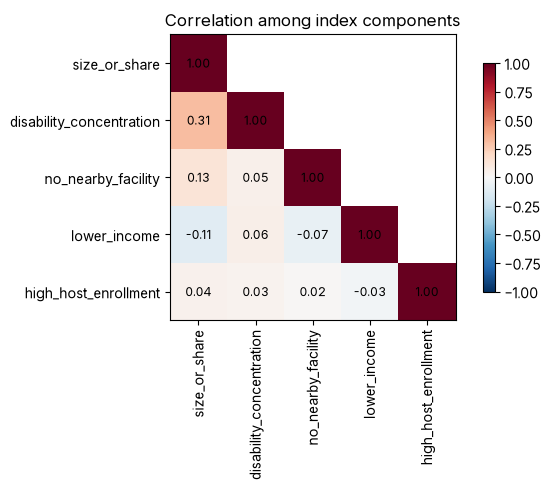

In [11]:
# Binary flags, disadvantage_score, and correlation check
def top_quartile_flag(series):
    return series >= series.quantile(0.75)

muni["high_learner_count"]            = top_quartile_flag(muni["total_sned_learners"])
muni["high_enrollment_share"]         = top_quartile_flag(muni["sned_prevalence_rate_per_1000"])
muni["high_disability_concentration"] = top_quartile_flag(muni["dominant_category_share"])

access_rate = 1 - muni["share_learners_without_access_to_facility"]
no_facility_threshold = access_rate.quantile(0.25)
muni["no_nearby_facility"] = access_rate <= no_facility_threshold

# income_rank is np.inf for SGA/Missing/Unmatched -- must guard explicitly, otherwise
# `inf > 3` evaluates True and silently mislabels unclassified munis as "lower income."
muni["lower_income"] = (muni["income_rank"] > HIGHER_INCOME_MAX_RANK) & np.isfinite(muni["income_rank"])

muni["high_host_school_enrollment"] = top_quartile_flag(muni["share_sned_learners_in_host_schools"])

muni["disadvantage_score"] = (
    (muni["high_learner_count"] | muni["high_enrollment_share"]).astype(int)
    + muni["high_disability_concentration"].astype(int)
    + muni["no_nearby_facility"].astype(int)
    + muni["lower_income"].astype(int)
    + muni["high_host_school_enrollment"].astype(int)
)

print("disadvantage_score distribution:")
print(muni["disadvantage_score"].value_counts().sort_index())

# --- Correlation check among the 5 score components ---
component_df = pd.DataFrame({
    "size_or_share":            (muni["high_learner_count"] | muni["high_enrollment_share"]).astype(int),
    "disability_concentration": muni["high_disability_concentration"].astype(int),
    "no_nearby_facility":       muni["no_nearby_facility"].astype(int),
    "lower_income":             muni["lower_income"].astype(int),
    "high_host_enrollment":     muni["high_host_school_enrollment"].astype(int),
})
disadvantage_corr = component_df.corr()
# display(disadvantage_corr.round(2))

mask = np.triu(np.ones(disadvantage_corr.shape, dtype=bool), k=1)  # True = upper triangle, excluding diagonal
corr_masked = np.ma.array(disadvantage_corr.values, mask=mask)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(corr_masked, vmin=-1, vmax=1, cmap="RdBu_r")
im.cmap.set_bad("white")  # masked (upper-triangle) cells render white instead of colormap's default

ax.set_xticks(range(len(disadvantage_corr.columns)))
ax.set_xticklabels(disadvantage_corr.columns, rotation=90, ha="center")
ax.set_yticks(range(len(disadvantage_corr.columns)))
ax.set_yticklabels(disadvantage_corr.columns)

for i in range(len(disadvantage_corr)):
    for j in range(i + 1):  # only annotate lower triangle + diagonal
        ax.text(j, i, f"{disadvantage_corr.values[i, j]:.2f}", ha="center", va="center", fontsize=9)

ax.set_title("Correlation among index components")
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
# plt.savefig(_ROOT / "figures" / "rq6_disadvantage_correlation_lower_triangle.png", dpi=200, bbox_inches="tight")
plt.show()


In [12]:
PASTEL = plt.cm.Set2.colors

_ordinal_classes = sorted(
    [c for c in muni.income_class_display.dropna().unique() if c not in [SGA_LABEL, MISSING_SOURCE_LABEL, UNMATCHED_LABEL]],
    key=_class_rank,
)
INCOME_CLASS_ORDER = _ordinal_classes + [SGA_LABEL, MISSING_SOURCE_LABEL, UNMATCHED_LABEL]
INCOME_CLASS_COLORS = dict(zip(INCOME_CLASS_ORDER, list(plt.cm.Set2.colors) + list(plt.cm.Pastel1.colors)))

muni["region_short"] = muni["psgc_region_name"].map(REGION_SHORT).fillna(muni["psgc_region_name"])

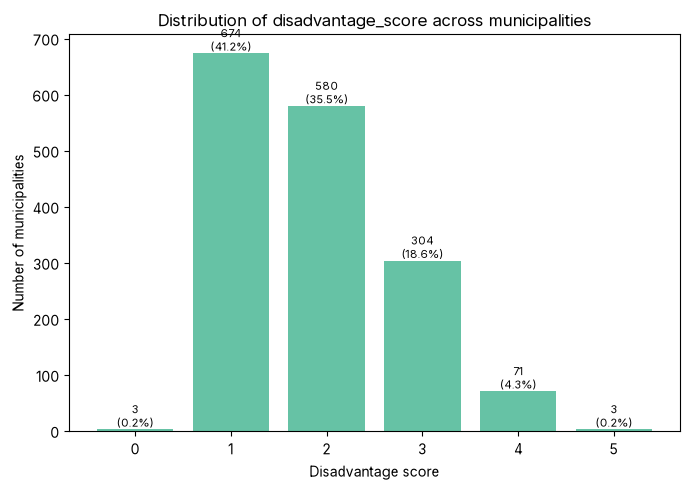

                    n_municipalities   pct
disadvantage_score                        
0                                  3   0.2
1                                674  41.2
2                                580  35.5
3                                304  18.6
4                                 71   4.3
5                                  3   0.2


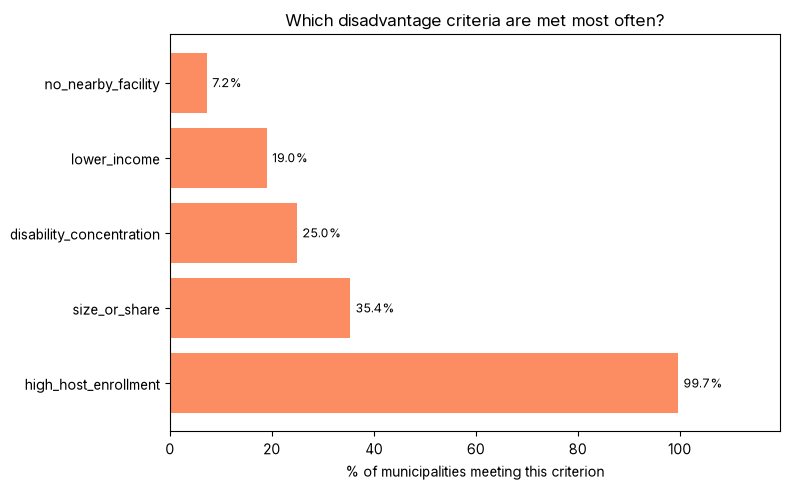

high_host_enrollment        99.7
size_or_share               35.4
disability_concentration    25.0
lower_income                19.0
no_nearby_facility           7.2
dtype: float64


In [14]:
# Disadvantage-score distribution & component frequency

# A. Overall score distribution
score_counts = muni["disadvantage_score"].value_counts().sort_index()
score_pct = (score_counts / score_counts.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(score_counts.index.astype(str), score_counts.values, color=PASTEL[0])
for x, (n, pct) in enumerate(zip(score_counts.values, score_pct.values)):
    ax.text(x, n + 5, f"{n}\n({pct}%)", ha="center", fontsize=8)
ax.set_xlabel("Disadvantage score")
ax.set_ylabel("Number of municipalities")
ax.set_title("Distribution of disadvantage_score across municipalities")
plt.tight_layout()
# plt.savefig(_ROOT / "figures" / "rq6_score_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

print(pd.DataFrame({"n_municipalities": score_counts, "pct": score_pct}))

# B. Which individual criterion is met most often, nationally?
component_freq = (component_df.mean() * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(component_freq.index, component_freq.values, color=PASTEL[1])
for y, v in enumerate(component_freq.values):
    ax.text(v + 1, y, f"{v:.1f}%", va="center", fontsize=9)
ax.set_xlabel("% of municipalities meeting this criterion")
ax.set_title("Which disadvantage criteria are met most often?")
ax.set_xlim(0, max(component_freq.values) * 1.2)
plt.tight_layout()
# plt.savefig(_ROOT / "figures" / "rq6_component_frequency.png", dpi=200, bbox_inches="tight")
plt.show()

print(component_freq.round(1))

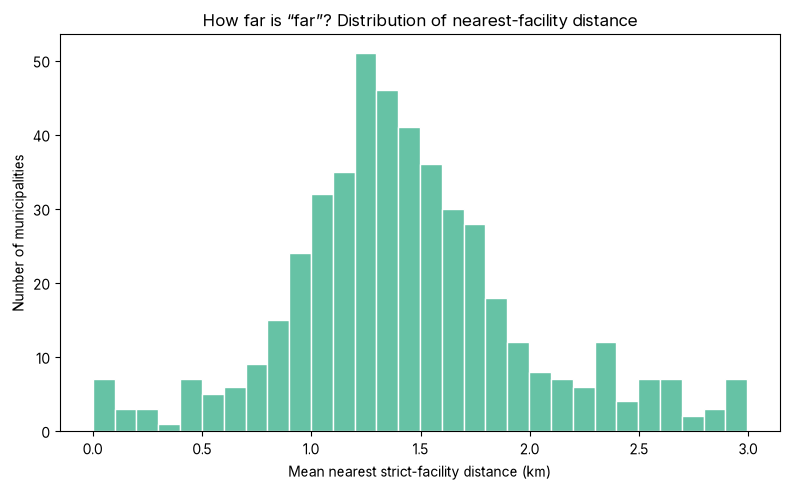

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(muni["mean_nearest_facility_distance_km"].dropna(), bins=30, color=PASTEL[0], edgecolor="white")
ax.set_xlabel("Mean nearest strict-facility distance (km)")
ax.set_ylabel("Number of municipalities")
ax.set_title("How far is \u201cfar\u201d? Distribution of nearest-facility distance")
plt.tight_layout()
# plt.savefig(_ROOT / "figures" / "insight4_distance_hist.png", dpi=200, bbox_inches="tight")
plt.show()
# Caveat: this is "distance among municipalities matched within the 3km search radius used to
# build the pairs table," not a true unconditional distance.

### **C. Facilities**

In [16]:
# Facility amster table, strict definition
def build_facility_load(pairs_df, school_totals):
    """Host-school vs. satellite-school learner load per facility."""
    m = pairs_df.merge(school_totals, left_on="population_school_id", right_on="beis_school_id", how="left")
    for c in ["n_diagnosed", "n_manifestation", "total_learners"]:
        m[c] = m[c].fillna(0)
    is_host = m.facility_school_id == m.population_school_id
    host = m[is_host].groupby("facility_school_id", as_index=False).agg(
        host_total=("total_learners", "sum"), host_diagnosed=("n_diagnosed", "sum"), host_manif=("n_manifestation", "sum"),
    )
    sat = m[~is_host].groupby("facility_school_id", as_index=False).agg(
        satellite_total=("total_learners", "sum"), satellite_diagnosed=("n_diagnosed", "sum"),
        satellite_manif=("n_manifestation", "sum"), n_satellite_schools=("population_school_id", "nunique"),
    )
    load = host.merge(sat, on="facility_school_id", how="outer").fillna(0)
    load["host_share"] = load.host_total / (load.host_total + load.satellite_total).replace(0, np.nan)
    return load

facility_load = build_facility_load(strict_pp_pairs, school_totals)

# Combined (host+satellite) top disability category for the facility's whole catchment
facility_cat = (
    strict_pp_pairs[["facility_school_id", "population_school_id"]]
    .merge(school_category_long.rename(columns={"beis_school_id": "population_school_id"}),
           on="population_school_id", how="left")
    .groupby(["facility_school_id", "Category"], as_index=False)["n_learners"].sum()
)
facility_cat_totals = facility_cat.groupby("facility_school_id")["n_learners"].sum().rename("cat_total")
facility_cat = facility_cat.merge(facility_cat_totals, on="facility_school_id")
facility_cat["cat_share"] = facility_cat.n_learners / facility_cat.cat_total.replace(0, np.nan)
top_cat = (
    facility_cat.sort_values("n_learners", ascending=False).drop_duplicates("facility_school_id")
    .rename(columns={"Category": "top_disability_category", "cat_share": "top_disability_share"})
    [["facility_school_id", "top_disability_category", "top_disability_share"]]
)

facility_master = strict_roster[["school_id", "school_name", "is_ilrc", "is_sped_center",
                                  "psgc_region_name", "psgc_province_name", "psgc_municity",
                                  "psgc_municity_name"]].copy()
facility_master["facility_type"] = np.select(
    [facility_master.is_ilrc & facility_master.is_sped_center, facility_master.is_ilrc, facility_master.is_sped_center],
    ["ILRC + SPED Center", "ILRC", "SPED Center"], default="Unclassified",
)
facility_master = facility_master.merge(school_ref[["school_id", "income_class_display"]], on="school_id", how="left")
facility_master = facility_master.merge(
    facility_load.rename(columns={"facility_school_id": "school_id"}), on="school_id", how="left"
)
facility_master = facility_master.merge(
    top_cat.rename(columns={"facility_school_id": "school_id"}), on="school_id", how="left"
)
load_cols = ["host_total", "host_diagnosed", "host_manif", "satellite_total",
             "satellite_diagnosed", "satellite_manif", "n_satellite_schools"]
facility_master[load_cols] = facility_master[load_cols].fillna(0)  # unroutable-coordinate facilities

facility_master["combined_total"] = facility_master.host_total + facility_master.satellite_total
facility_master = facility_master.rename(columns={"host_total": "host_enrollment", "satellite_total": "satellite_enrollment"})
facility_master = facility_master.drop(columns=["is_ilrc", "is_sped_center"])

print(f"Facility master table: {facility_master.shape[0]} rows, {facility_master.shape[1]} columns")
facility_master.sort_values("combined_total", ascending=False).head(10)

Facility master table: 495 rows, 19 columns


,school_id,school_name,psgc_region_name,psgc_province_name,psgc_municity,psgc_municity_name,facility_type,income_class_display,host_enrollment,host_diagnosed,host_manif,satellite_enrollment,satellite_diagnosed,satellite_manif,n_satellite_schools,host_share,top_disability_category,top_disability_share,combined_total
467,500331,Isaac Lopez Integrated School (Isaac Lopez ES),National Capital Region (NCR),City of Mandaluyong,1380500000,City of Mandaluyong,SPED Center,1st,299.0,228.0,71.0,2967.0,1803.0,1164.0,55.0,0.091549,Autism Spectrum Disorder,0.313840,3266.0
493,502655,Kabayanan Integrated School,National Capital Region (NCR),City of San Juan,1381400000,City of San Juan,SPED Center,1st,131.0,87.0,44.0,3027.0,1510.0,1517.0,58.0,0.041482,Difficulty in Seeing,0.215326,3158.0
335,129557,Kapt. T. Monteverde Sr. CES,Region XI (Davao Region),City of Davao,1130700000,City of Davao,SPED Center,1st,219.0,158.0,61.0,1911.0,784.0,1127.0,53.0,0.102817,Autism Spectrum Disorder,0.223005,2130.0
392,136467,P. Burgos ES,National Capital Region (NCR),City of Manila,1380606000,Sampaloc,SPED Center,1st,389.0,367.0,22.0,1593.0,841.0,752.0,59.0,0.196266,Autism Spectrum Disorder,0.369828,1982.0
388,136452,Padre Gomez Elementary School,National Capital Region (NCR),City of Manila,1380605000,Santa Cruz,ILRC + SPED Center,1st,451.0,436.0,15.0,1470.0,1308.0,162.0,61.0,0.234774,Autism Spectrum Disorder,0.471629,1921.0
337,129717,Davao City Special School,Region XI (Davao Region),City of Davao,1130700000,City of Davao,ILRC,1st,528.0,491.0,37.0,1390.0,561.0,829.0,29.0,0.275287,Autism Spectrum Disorder,0.277372,1918.0
386,136432,J. P. Rizal Elementary School,National Capital Region (NCR),City of Manila,1380601000,Tondo I/II,SPED Center,1st,705.0,657.0,48.0,1206.0,946.0,260.0,83.0,0.368917,Autism Spectrum Disorder,0.436421,1911.0
389,136457,Dr. A. Albert Elementary School,National Capital Region (NCR),City of Manila,1380606000,Sampaloc,SPED Center,1st,155.0,135.0,20.0,1744.0,1444.0,300.0,62.0,0.081622,Autism Spectrum Disorder,0.463928,1899.0
387,136444,Gen. Maximino Hizon Elementary School,National Capital Region (NCR),City of Manila,1380601000,Tondo I/II,SPED Center,1st,302.0,290.0,12.0,1553.0,1291.0,262.0,74.0,0.162803,Autism Spectrum Disorder,0.444205,1855.0
241,119915,San Nicolas ES,Region VII (Central Visayas),City of Cebu,0730600000,City of Cebu,SPED Center,1st,111.0,68.0,43.0,1634.0,965.0,669.0,60.0,0.063610,Autism Spectrum Disorder,0.232092,1745.0


### **D. Cluster master**

In [17]:
def build_cluster_table(pairs_df, facility_roster):
    """Bipartite facility<->school graph from an access-pairs table. Returns the graph,
    a per-cluster size table, and a node -> cluster_id lookup."""
    G = nx.Graph()
    G.add_nodes_from(facility_roster.school_id, is_facility=True)
    non_self = pairs_df[pairs_df.facility_school_id != pairs_df.population_school_id]
    G.add_edges_from(zip(non_self.facility_school_id, non_self.population_school_id))
    components = list(nx.connected_components(G))
    facility_ids = set(facility_roster.school_id)
    rows, cluster_id_map = [], {}
    for i, comp in enumerate(components):
        facs_in_comp = comp & facility_ids
        for node in comp:
            cluster_id_map[node] = i
        rows.append({"cluster_id": i, "n_facilities": len(facs_in_comp), "n_schools_total": len(comp)})
    cluster_sizes = pd.DataFrame(rows)
    return G, cluster_sizes, cluster_id_map

strict_roster["is_routable"] = strict_roster.school_id.isin(pp_pairs.facility_school_id)
routable_strict_roster = strict_roster[strict_roster.is_routable].copy()
n_unroutable = (~strict_roster.is_routable).sum()
if n_unroutable:
    print(f"[NOTE] {n_unroutable} strict facilities excluded from clustering -- unroutable coordinates.")

G, cluster_sizes, cluster_id_map = build_cluster_table(strict_pp_pairs, routable_strict_roster)
print(f"Total clusters: {cluster_sizes.shape[0]}")
print(f"Singleton clusters: {(cluster_sizes.n_facilities == 1).sum()} / {len(cluster_sizes)}")

node_to_cluster = pd.Series(cluster_id_map, name="cluster_id").rename_axis("school_id").reset_index()
node_to_cluster["school_id"] = node_to_cluster["school_id"].astype("string")

cluster_membership = node_to_cluster.merge(
    school_totals.rename(columns={"beis_school_id": "school_id"}), on="school_id", how="left"
)
cluster_membership[["n_diagnosed", "n_manifestation", "total_learners"]] = cluster_membership[
    ["n_diagnosed", "n_manifestation", "total_learners"]
].fillna(0)
cluster_membership = cluster_membership.merge(
    school_ref[["school_id", "psgc_municity", "psgc_municity_name", "income_class_display"]],
    on="school_id", how="left",
)
cluster_membership["is_host"] = cluster_membership.school_id.isin(strict_roster.school_id)

cluster_agg = cluster_membership.groupby("cluster_id", as_index=False).agg(
    cluster_school_count=("school_id", "nunique"),
    cluster_sned_learners=("total_learners", "sum"),
    municipality=("psgc_municity_name", _mode_or_first),
    income_class_display=("income_class_display", _mode_or_first),
    income_class_diversity=("income_class_display", "nunique"),
    # NOTE: diversity counts "Missing"/"SGA"/"Unmatched" as distinct labels too, which can
    # overstate genuine income-class spanning for a cluster with mostly-clean data plus one
    # unmatched school. Worth a second look before reading a diversity>1 cluster as
    # "genuinely straddles income classes."
)
host_learners_c = (
    cluster_membership[cluster_membership.is_host].groupby("cluster_id")["total_learners"].sum()
    .rename("host_school_learners")
)
cluster_agg = cluster_agg.merge(host_learners_c.reset_index(), on="cluster_id", how="left")
cluster_agg["host_school_learners"] = cluster_agg["host_school_learners"].fillna(0)
cluster_agg["satellite_school_learners"] = cluster_agg.cluster_sned_learners - cluster_agg.host_school_learners
cluster_agg = cluster_agg.merge(cluster_sizes, on="cluster_id", how="left")

# cluster_access_rate: by construction, every school in the graph is <=3km from at least
# one facility in ITS OWN cluster, so this reads ~100% almost everywhere. Kept as an
# explicit sanity-check column, not a discriminating metric -- a cluster where this is
# NOT ~100% flags a data problem, not a genuine access gap.
cluster_agg["cluster_access_rate"] = 1.0

# Dominant disability per cluster
cluster_cat = (
    cluster_membership[["school_id", "cluster_id"]]
    .merge(school_category_long.rename(columns={"beis_school_id": "school_id"}), on="school_id", how="left")
    .groupby(["cluster_id", "Category"], as_index=False)["n_learners"].sum()
)
cluster_cat_totals = cluster_cat.groupby("cluster_id")["n_learners"].sum().rename("cat_total")
cluster_cat = cluster_cat.merge(cluster_cat_totals, on="cluster_id")
cluster_cat["cat_share"] = cluster_cat.n_learners / cluster_cat.cat_total.replace(0, np.nan)
cluster_dominant = (
    cluster_cat.sort_values("n_learners", ascending=False).drop_duplicates("cluster_id")
    .rename(columns={"Category": "dominant_disability", "cat_share": "dominant_disability_share"})
    [["cluster_id", "dominant_disability", "dominant_disability_share"]]
)
cluster_agg = cluster_agg.merge(cluster_dominant, on="cluster_id", how="left")

# host_center_id: the single facility with the largest combined (host+satellite) load in
# the cluster. Unambiguous for singleton clusters; for multi-facility clusters it names the
# "primary" node only -- n_facilities_in_cluster tells you when there's more than one.
facility_combined = facility_master[["school_id", "combined_total"]].rename(columns={"school_id": "facility_school_id"})
facility_cluster = node_to_cluster.rename(columns={"school_id": "facility_school_id"}).merge(
    facility_combined, on="facility_school_id", how="inner"
)
host_center = (
    facility_cluster.sort_values("combined_total", ascending=False).drop_duplicates("cluster_id")
    .rename(columns={"facility_school_id": "host_center_id"})[["cluster_id", "host_center_id"]]
)
cluster_agg = cluster_agg.merge(host_center, on="cluster_id", how="left")

cluster_agg["cluster_type"] = np.where(cluster_agg.n_facilities == 1, "singleton", "multi-facility")
cluster_agg["cluster_profile"] = cluster_agg["cluster_type"] + ", " + cluster_agg["income_class_display"].astype(str)

cluster_master = cluster_agg.rename(columns={"n_facilities": "n_facilities_in_cluster"})[[
    "cluster_id", "host_center_id", "n_facilities_in_cluster", "cluster_type",
    "municipality", "income_class_display", "income_class_diversity",
    "cluster_school_count", "cluster_sned_learners", "host_school_learners",
    "satellite_school_learners", "cluster_access_rate", "dominant_disability",
    "dominant_disability_share", "cluster_profile",
]]

print(f"\nCluster master table: {cluster_master.shape[0]} rows, {cluster_master.shape[1]} columns")
cluster_master.sort_values("cluster_sned_learners", ascending=False).head(10)

[NOTE] 3 strict facilities excluded from clustering -- unroutable coordinates.
Total clusters: 413
Singleton clusters: 378 / 413

Cluster master table: 413 rows, 15 columns


,cluster_id,host_center_id,n_facilities_in_cluster,cluster_type,municipality,income_class_display,income_class_diversity,cluster_school_count,cluster_sned_learners,host_school_learners,satellite_school_learners,cluster_access_rate,dominant_disability,dominant_disability_share,cluster_profile
341,341,500331,19,multi-facility,City of Caloocan,1st,2,442,13095.0,4428.0,8667.0,1.0,Autism Spectrum Disorder,0.385796,"multi-facility, 1st"
211,211,119915,5,multi-facility,City of Cebu,1st,2,160,3963.0,530.0,3433.0,1.0,"Difficulty in Remembering, Concentrating, Payi...",0.253596,"multi-facility, 1st"
291,291,129557,4,multi-facility,City of Davao,1st,2,94,3802.0,710.0,3092.0,1.0,Autism Spectrum Disorder,0.248027,"multi-facility, 1st"
342,342,136560,6,multi-facility,City of Marikina,1st,2,158,3414.0,1225.0,2189.0,1.0,Autism Spectrum Disorder,0.422671,"multi-facility, 1st"
75,75,107139,3,multi-facility,City of Olongapo,1st,1,48,2244.0,786.0,1458.0,1.0,"Difficulty in Remembering, Concentrating, Payi...",0.317291,"multi-facility, 1st"
85,85,107916,4,multi-facility,City of Dasmariñas,1st,2,65,2024.0,862.0,1162.0,1.0,Autism Spectrum Disorder,0.276680,"multi-facility, 1st"
295,295,129717,1,singleton,City of Davao,1st,1,30,1918.0,528.0,1390.0,1.0,Autism Spectrum Disorder,0.277372,"singleton, 1st"
84,84,108213,2,multi-facility,City of Biñan,1st,2,67,1816.0,398.0,1418.0,1.0,Autism Spectrum Disorder,0.246145,"multi-facility, 1st"
346,346,136903,4,multi-facility,City of Muntinlupa,1st,2,39,1624.0,776.0,848.0,1.0,Autism Spectrum Disorder,0.323276,"multi-facility, 1st"
343,343,136547,2,multi-facility,Quezon City,1st,2,33,1447.0,306.0,1141.0,1.0,Autism Spectrum Disorder,0.429164,"multi-facility, 1st"


### **E. Visualizations**

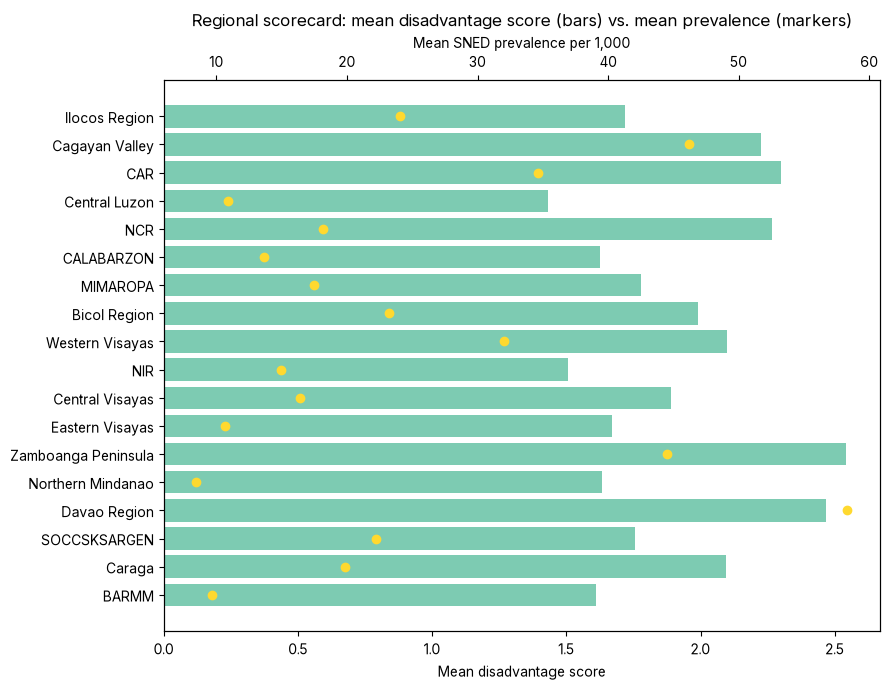

,mean_disadvantage_score,mean_prevalence,n_municipalities
region_short,,,
BARMM,1.61,9.68,108
Caraga,2.10,19.83,73
SOCCSKSARGEN,1.76,22.24,49
Davao Region,2.47,58.33,49
Northern Mindanao,1.63,8.46,93
Zamboanga Peninsula,2.54,44.47,72
Eastern Visayas,1.67,10.67,143
Central Visayas,1.89,16.38,101
NIR,1.51,14.95,63


In [18]:
regional_scorecard = muni.groupby("region_short").agg(
    mean_disadvantage_score=("disadvantage_score", "mean"),
    mean_prevalence=("sned_prevalence_rate_per_1000", "mean"),
    n_municipalities=("psgc_municity", "nunique"),
).reindex(REGION_ORDER[::-1])  # reversed so the first region in REGION_ORDER plots at the top

fig, ax1 = plt.subplots(figsize=(9, 7))
ax1.barh(regional_scorecard.index, regional_scorecard.mean_disadvantage_score, color=PASTEL[0], alpha=0.85)
ax1.set_xlabel("Mean disadvantage score")
ax2 = ax1.twiny()
ax2.plot(regional_scorecard.mean_prevalence, regional_scorecard.index, marker="o", color=PASTEL[5], lw=0)
ax2.set_xlabel("Mean SNED prevalence per 1,000")
ax1.set_title("Regional scorecard: mean disadvantage score (bars) vs. mean prevalence (markers)")
ax1.invert_yaxis()
ax2.invert_yaxis()
plt.tight_layout()
# plt.savefig(_ROOT / "figures" / "rq6_regional_scorecard.png", dpi=200, bbox_inches="tight")
plt.show()

regional_scorecard.round(2)

In [19]:
# Chloropleth setup
geo = gpd.read_file(DATA / "external" / "consolidated_geodata_matched.gpkg")
geo = cast_ids_to_str(geo, cols=["adm1_psgc", "adm2_psgc", "adm3_psgc"], zfill_cols=["adm3_psgc"])

print(f"Rows: {len(geo):,}, all geo_level == 'Bgy': {(geo.geo_level == 'Bgy').all()}")

# NIR fix
usable = geo.copy()
NIR_PROVINCES = {"NEGROS OCCIDENTAL", "NEGROS ORIENTAL", "SIQUIJOR"}
is_nir = usable["adm2_en"].str.strip().str.upper().isin(NIR_PROVINCES)
print(f"{is_nir.sum():,} barangay rows reassigned to NIR (still coded under old Region 06/07 in this file).")

usable.loc[is_nir, "adm1_en"] = "Negros Island Region (NIR)"
usable.loc[is_nir, "adm3_psgc"] = "18" + usable.loc[is_nir, "adm3_psgc"].str[2:]

usable["psgc_code"] = usable["adm3_psgc"].astype("Int64").astype("string").str.zfill(10)
print(f"Distinct psgc_code (candidate municipality polygons after dissolve): {usable.psgc_code.nunique():,}")

# Municipality dissolve
muni_geo = (
    usable[["psgc_code", "adm3_en", "adm2_en", "adm1_en", "area_km2", "geometry"]]
    .dissolve(by="psgc_code", aggfunc={"adm3_en": "first", "adm2_en": "first", "adm1_en": "first", "area_km2": "sum"})
    .reset_index()
)
print(f"Municipality polygons after dissolve: {len(muni_geo):,}")

match_rate = muni["psgc_municity"].isin(muni_geo["psgc_code"]).mean()
print(f"[QA] Municipalities in the master table with a matching polygon: {match_rate:.1%}")

nir_muni_check = muni[muni.psgc_region_name.str.contains("Negros Island", case=False, na=False)]
if len(nir_muni_check):
    nir_match_rate = nir_muni_check["psgc_municity"].isin(muni_geo["psgc_code"]).mean()
    print(f"[QA] NIR municipalities specifically: {len(nir_muni_check)} in master table, "
          f"{nir_match_rate:.1%} now matched to a polygon")
else:
    print("[QA] No NIR municipalities found in muni table via 'Negros Island' substring -- check psgc_region_name spelling")

unmatched_munis = muni[~muni["psgc_municity"].isin(muni_geo["psgc_code"])]
if len(unmatched_munis):
    print(f"[QA] {len(unmatched_munis)} municipalities still unmatched. Sample:")
    display(unmatched_munis[["psgc_municity", "psgc_municity_name", "psgc_region_name"]].head(10))

muni_mapped = muni_geo.merge(muni, left_on="psgc_code", right_on="psgc_municity", how="left")

Rows: 42,048, all geo_level == 'Bgy': False
1,353 barangay rows reassigned to NIR (still coded under old Region 06/07 in this file).
Distinct psgc_code (candidate municipality polygons after dissolve): 1,582
Municipality polygons after dissolve: 1,582
[QA] Municipalities in the master table with a matching polygon: 95.5%
[QA] NIR municipalities specifically: 63 in master table, 98.4% now matched to a polygon
[QA] 74 municipalities still unmatched. Sample:


,psgc_municity,psgc_municity_name,psgc_region_name
0,1130700000,City of Davao,Region XI (Davao Region)
2,0931700000,City of Zamboanga,Region IX (Zamboanga Peninsula)
3,1630400000,City of Butuan,Region XIII (Caraga)
4,1731500000,City of Puerto Princesa,MIMAROPA Region
9,0731100000,City of Lapu-Lapu,Region VII (Central Visayas)
10,1030900000,City of Iligan,Region X (Northern Mindanao)
21,1430300000,City of Baguio,Cordillera Administrative Region (CAR)
35,1230800000,City of General Santos,Region XII (SOCCSKSARGEN)
36,0631000000,City of Iloilo,Region VI (Western Visayas)
131,1830200000,City of Bacolod,Negros Island Region (NIR)


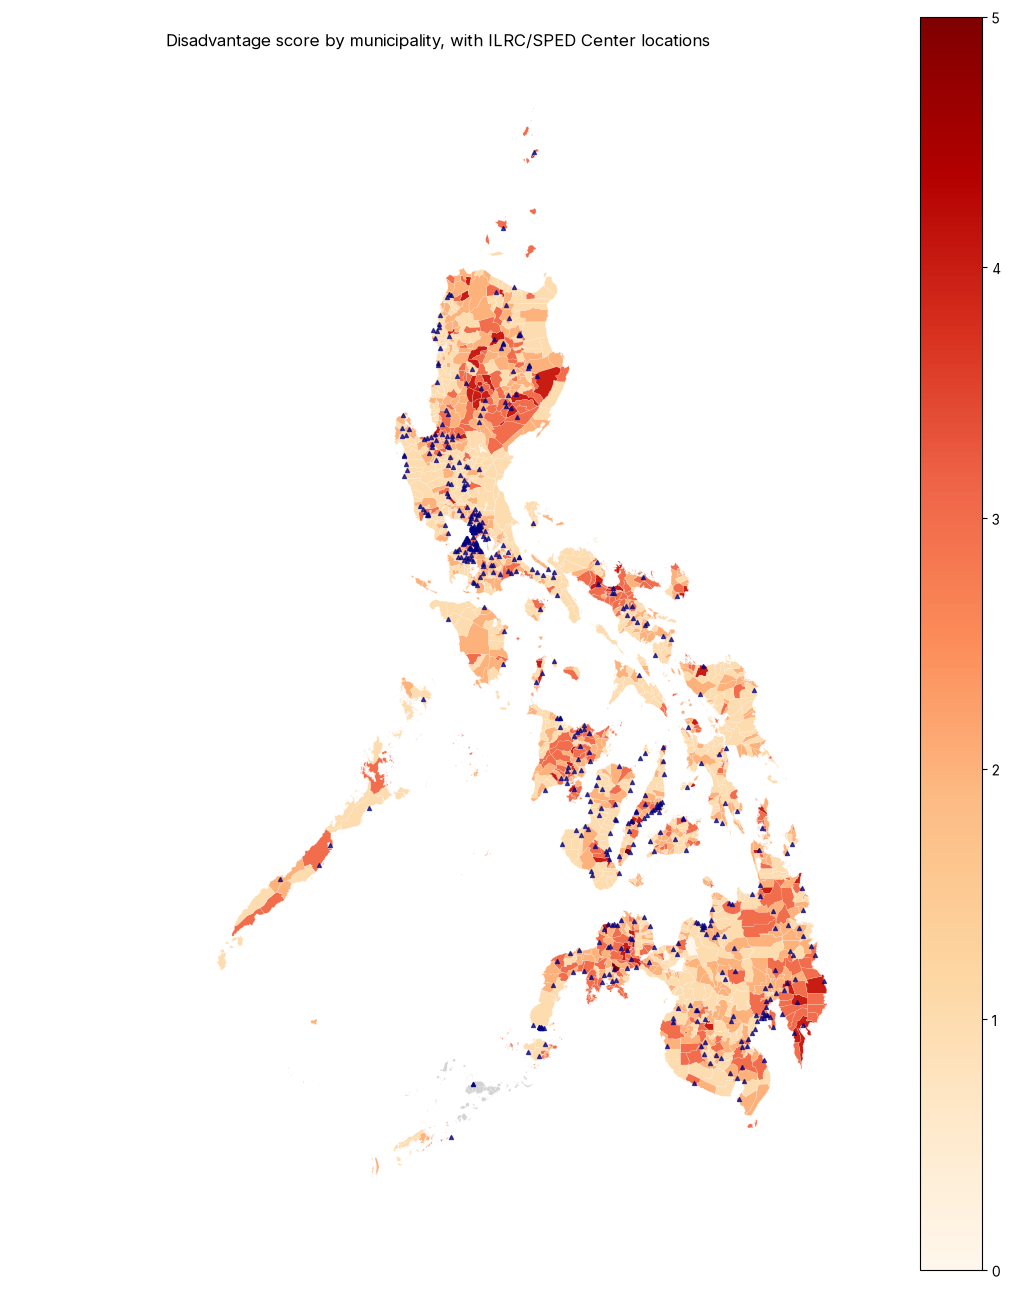

In [20]:
# Disadvantage score
fig, ax = plt.subplots(figsize=(11, 13))
muni_mapped.plot(column="disadvantage_score", cmap="OrRd", linewidth=0.1, edgecolor="white",
                  legend=True, ax=ax, missing_kwds={"color": "lightgrey", "label": "No boundary data"})

facility_points = gpd.GeoDataFrame(
    strict_roster, geometry=gpd.points_from_xy(strict_roster.longitude, strict_roster.latitude),
    crs=muni_mapped.crs,
)
facility_points.plot(ax=ax, markersize=8, color="navy", marker="^", alpha=0.7)

ax.set_title("Disadvantage score by municipality, with ILRC/SPED Center locations")
ax.axis("off")
plt.tight_layout()
# plt.savefig(_ROOT / "figures" / "rq6_map_disadvantage_score.png", dpi=250, bbox_inches="tight")
plt.show()

In [22]:
cluster_membership_sizes = cluster_membership.merge(cluster_sizes[["cluster_id", "n_facilities"]], on="cluster_id", how="left")
muni_cluster_status = cluster_membership_sizes.groupby("psgc_municity").agg(
    any_multi_facility=("n_facilities", lambda s: (s > 1).any()),
    n_clusters_touching=("cluster_id", "nunique"),
).reset_index()

muni_cluster_full = muni[["psgc_municity"]].merge(muni_cluster_status, on="psgc_municity", how="left")
muni_cluster_full["any_multi_facility"] = muni_cluster_full["any_multi_facility"].fillna(False)
muni_cluster_full["n_clusters_touching"] = muni_cluster_full["n_clusters_touching"].fillna(0)

def _reach_status(row):
    if row["any_multi_facility"]:
        return "Multi-facility cluster reach"
    elif row["n_clusters_touching"] > 0:
        return "Singleton-cluster reach only"
    else:
        return "No cluster reach (desert)"

muni_cluster_full["cluster_reach_status"] = muni_cluster_full.apply(_reach_status, axis=1)
muni = muni.merge(muni_cluster_full[["psgc_municity", "cluster_reach_status"]], on="psgc_municity", how="left")

print(muni["cluster_reach_status"].value_counts())

cluster_reach_status
No cluster reach (desert)       1162
Singleton-cluster reach only     393
Multi-facility cluster reach      80
Name: count, dtype: int64


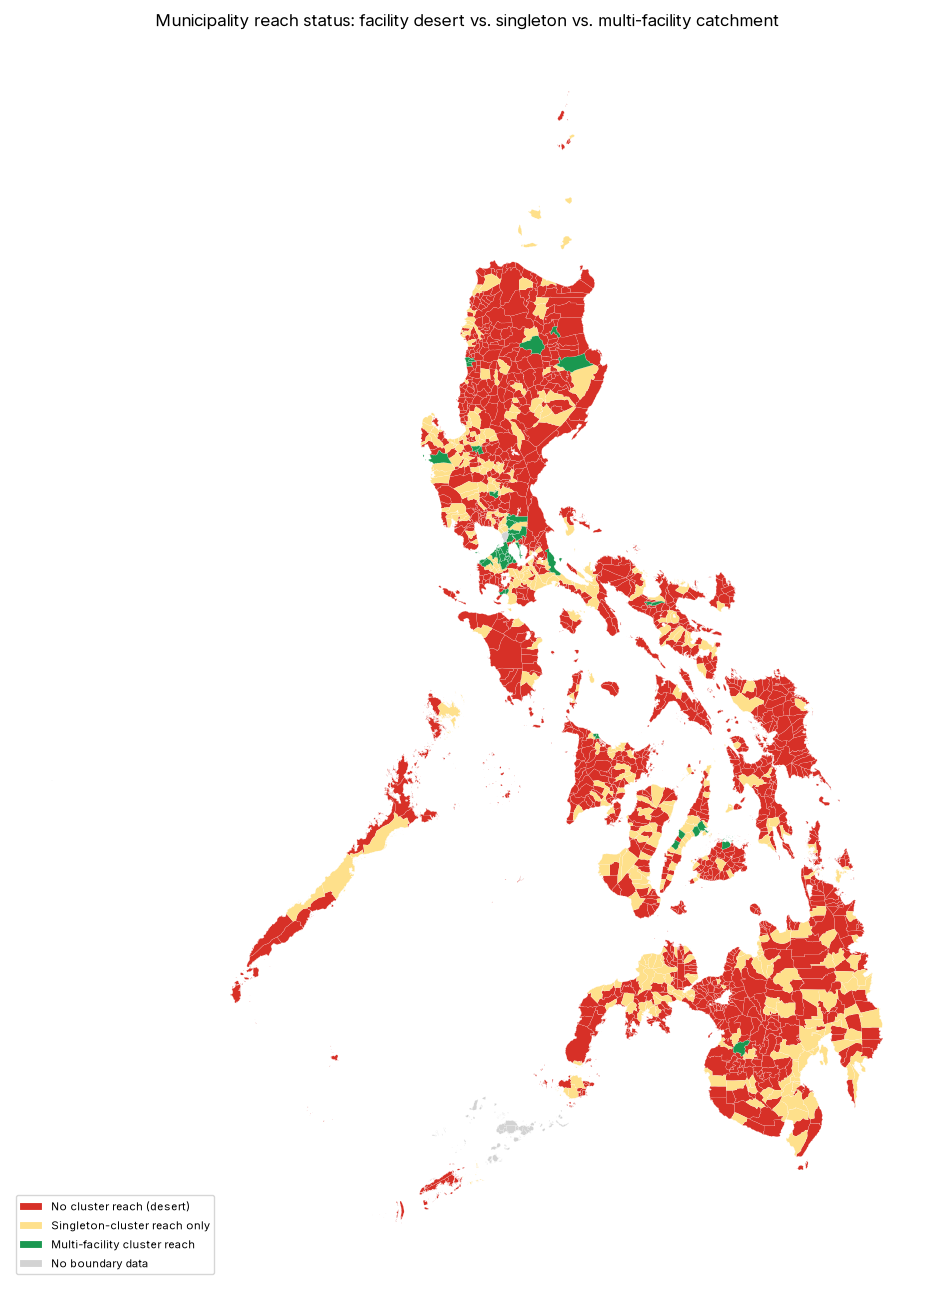

In [23]:
# Cluster reach-status choropleth
muni_mapped2 = muni_geo.merge(
    muni[["psgc_municity", "cluster_reach_status"]], left_on="psgc_code", right_on="psgc_municity", how="left"
)
STATUS_COLORS = {
    "No cluster reach (desert)": "#d73027",
    "Singleton-cluster reach only": "#fee08b",
    "Multi-facility cluster reach": "#1a9850",
}
fig, ax = plt.subplots(figsize=(11, 13))
for status, color in STATUS_COLORS.items():
    muni_mapped2[muni_mapped2.cluster_reach_status == status].plot(
        ax=ax, color=color, linewidth=0.1, edgecolor="white", label=status
    )
muni_mapped2[muni_mapped2.cluster_reach_status.isna()].plot(
    ax=ax, color="lightgrey", linewidth=0.1, edgecolor="white", label="No boundary data"
)
ax.set_title("Municipality reach status: facility desert vs. singleton vs. multi-facility catchment")
ax.axis("off")
ax.legend(loc="lower left", fontsize=8)
plt.tight_layout()
# plt.savefig(_ROOT / "figures" / "rq6_map_cluster_reach_status.png", dpi=250, bbox_inches="tight")
plt.show()

### **F. Additionals**

In [ ]:
# 1. Unserved school clusters
from sklearn.cluster import DBSCAN

school_coords = pd.concat([
    pub_coords[["school_id", "latitude", "longitude"]],
    priv_coords[["school_id", "latitude", "longitude"]],
], ignore_index=True)

unserved = access[~access.has_strict_facility_within_3km].merge(
    school_coords, left_on="population_school_id", right_on="school_id", how="left"
).dropna(subset=["latitude", "longitude"])

EARTH_RADIUS_KM = 6371.0
DESERT_EPS_KM = 3  # same 3km yardstick used everywhere else in this project

coords_rad = np.radians(unserved[["latitude", "longitude"]].values)
db = DBSCAN(eps=DESERT_EPS_KM / EARTH_RADIUS_KM, min_samples=2, metric="haversine", algorithm="ball_tree").fit(coords_rad)
unserved["desert_cluster_id"] = db.labels_  # -1 = isolated, not part of a cluster

n_clustered = (unserved.desert_cluster_id != -1).sum()
print(f"Unserved schools: {len(unserved):,}")
print(f"  In a desert cluster (>=2 unserved schools within 3km of each other): {n_clustered:,}")
print(f"  Isolated (no other unserved school within 3km): {(unserved.desert_cluster_id == -1).sum():,}")

desert_clusters = unserved[unserved.desert_cluster_id != -1].groupby("desert_cluster_id").agg(
    n_schools=("population_school_id", "nunique"),
    total_learners=("total_learners", "sum"),
    municipalities=("psgc_municity_name", lambda s: sorted(s.dropna().unique())),
).reset_index()

muni_score_lookup = muni.groupby("psgc_municity_name")["disadvantage_score"].mean()
desert_clusters["mean_disadvantage_score"] = desert_clusters["municipalities"].apply(
    lambda munis: muni_score_lookup.reindex(munis).mean()
)

# Priority definition: a genuinely sizeable cluster (>=3 schools) sitting in
# high-disadvantage territory (mean score >= 3 out of 5) -- adjust these two
# thresholds freely, they're the only "definition" here.
MIN_CLUSTER_SIZE = 3
MIN_MEAN_SCORE = 3
desert_clusters["is_priority"] = (
    (desert_clusters.n_schools >= MIN_CLUSTER_SIZE) & (desert_clusters.mean_disadvantage_score >= MIN_MEAN_SCORE)
)

print(f"\nPriority unserved clusters (>= {MIN_CLUSTER_SIZE} schools, mean disadvantage score >= {MIN_MEAN_SCORE}): "
      f"{desert_clusters.is_priority.sum()} / {len(desert_clusters)}")
desert_clusters.sort_values(["is_priority", "total_learners"], ascending=False).head(15)

Unserved schools: 47,658
  In a desert cluster (>=2 unserved schools within 3km of each other): 46,297
  Isolated (no other unserved school within 3km): 1,361

Priority unserved clusters (>= 3 schools, mean disadvantage score >= 3): 205 / 1677


,desert_cluster_id,n_schools,total_learners,municipalities,mean_disadvantage_score,is_priority
1207,1207,40,2839.0,"[Banaybanay, Lupon]",3.000000,True
351,351,62,2571.0,"[Caraga, Manay]",3.000000,True
1211,1211,22,1551.0,"[Boston, Cateel]",3.000000,True
1216,1216,17,1195.0,[Governor Generoso],3.000000,True
1237,1237,17,1003.0,[City of Mati ],4.000000,True
1231,1231,3,760.0,[Manay],3.000000,True
1203,1203,9,732.0,[Baganga],4.000000,True
1603,1603,116,656.0,"[Balbalan, City of Tabuk , Lubuagan, Pasil, Pi...",3.142857,True
164,164,21,648.0,"[Maddela, Nagtipunan]",3.000000,True
1244,1244,15,630.0,[Tarragona],3.000000,True


In [25]:
# 2. Facility enrollment burden + singleton flag
facility_cluster_type = node_to_cluster.merge(
    cluster_sizes[["cluster_id", "n_facilities"]], on="cluster_id", how="left"
)
facility_cluster_type["is_singleton_cluster"] = facility_cluster_type["n_facilities"] == 1
facility_cluster_type = facility_cluster_type.rename(columns={"school_id": "facility_school_id"})

facility_burden = facility_master.merge(
    facility_cluster_type[["facility_school_id", "is_singleton_cluster"]].rename(columns={"facility_school_id": "school_id"}),
    on="school_id", how="left",
)
facility_burden = facility_burden.sort_values("combined_total", ascending=False)

print("Top 15 facilities by total enrollment served (host + satellite):")
display(facility_burden[["school_name", "facility_type", "psgc_municity_name", "income_class_display",
                          "combined_total", "n_satellite_schools", "is_singleton_cluster"]].head(15))

high_burden_singleton = facility_burden[facility_burden.is_singleton_cluster & (facility_burden.combined_total >= facility_burden.combined_total.quantile(0.75))]
print(f"\nHigh-burden AND singleton (top-quartile enrollment, no redundant facility nearby): {len(high_burden_singleton)}")
display(high_burden_singleton[["school_name", "psgc_municity_name", "combined_total", "n_satellite_schools"]])

Top 15 facilities by total enrollment served (host + satellite):


,school_name,facility_type,psgc_municity_name,income_class_display,combined_total,n_satellite_schools,is_singleton_cluster
467,Isaac Lopez Integrated School (Isaac Lopez ES),SPED Center,City of Mandaluyong,1st,3266.0,55.0,False
493,Kabayanan Integrated School,SPED Center,City of San Juan,1st,3158.0,58.0,False
335,Kapt. T. Monteverde Sr. CES,SPED Center,City of Davao,1st,2130.0,53.0,False
392,P. Burgos ES,SPED Center,Sampaloc,1st,1982.0,59.0,False
388,Padre Gomez Elementary School,ILRC + SPED Center,Santa Cruz,1st,1921.0,61.0,False
337,Davao City Special School,ILRC,City of Davao,1st,1918.0,29.0,True
386,J. P. Rizal Elementary School,SPED Center,Tondo I/II,1st,1911.0,83.0,False
389,Dr. A. Albert Elementary School,SPED Center,Sampaloc,1st,1899.0,62.0,False
387,Gen. Maximino Hizon Elementary School,SPED Center,Tondo I/II,1st,1855.0,74.0,False
241,San Nicolas ES,SPED Center,City of Cebu,1st,1745.0,60.0,False



High-burden AND singleton (top-quartile enrollment, no redundant facility nearby): 53


,school_name,psgc_municity_name,combined_total,n_satellite_schools
337,Davao City Special School,City of Davao,1918.0,29.0
79,Angeles Elementary School,City of Angeles,1384.0,49.0
404,Bagong Silang Elementary School,City of Caloocan,1334.0,48.0
384,Baguio SPED Center,City of Baguio,1280.0,46.0
150,Lucena West I Elementary School,City of Lucena,1256.0,45.0
208,BACOLOD CITY SPED CENTER,City of Bacolod,1252.0,41.0
409,Paranaque Elementary School Central,City of Parañaque,1018.0,30.0
466,General Santos City SPED Integrated School,City of General Santos,1009.0,14.0
470,Antipolo City SPED Center,City of Antipolo,1003.0,47.0
336,Piedad Central ES,City of Davao,982.0,19.0


### **G. Exports**

In [27]:
# ==========================================================================
# EXPORT — Disadvantage index per municipality, with the flag for each of
# RQ6's five dimensions.
# ==========================================================================
EXPORT_DIR = DATA / "exports"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

DIM_COLS = {
    "high_learner_count":            "dim_a1_high_learner_count",
    "high_enrollment_share":         "dim_a2_high_enrollment_share",
    "high_disability_concentration": "dim_b_high_disability_concentration",
    "no_nearby_facility":            "dim_c_no_nearby_facility",
    "high_host_school_enrollment":   "dim_d_high_host_school_enrollment",
    "lower_income":                  "dim_e_lower_income",
}

disadvantage_export = muni[
    ["psgc_municity", "psgc_municity_name", "psgc_province_name", "psgc_region_name", "region_short",
     "income_class_display", "disadvantage_score"] + list(DIM_COLS.keys())
].rename(columns=DIM_COLS).sort_values("disadvantage_score", ascending=False)

disadvantage_export.to_csv(EXPORT_DIR / "q6_disadvantage_index_by_municipality.csv", index=False)
print(f"Saved {len(disadvantage_export):,} rows -> {EXPORT_DIR / 'q6_disadvantage_index_by_municipality.csv'}")
disadvantage_export.head()


Saved 1,635 rows -> c:\Users\Lanz Railey Fermin\Desktop\ecair_work\sned-analysis\data\exports\q6_disadvantage_index_by_municipality.csv


,psgc_municity,psgc_municity_name,psgc_province_name,psgc_region_name,region_short,income_class_display,disadvantage_score,dim_a1_high_learner_count,dim_a2_high_enrollment_share,dim_b_high_disability_concentration,dim_c_no_nearby_facility,dim_d_high_host_school_enrollment,dim_e_lower_income
1523,0702212000,Boljoon,Cebu,Region VII (Central Visayas),Central Visayas,4th,5,False,True,True,True,True,True
1084,0907344000,Tigbao,Zamboanga del Sur,Region IX (Zamboanga Peninsula),Zamboanga Peninsula,4th,5,False,True,True,True,True,True
1594,0501709000,Camaligan,Camarines Sur,Region V (Bicol Region),Bicol Region,4th,5,False,True,True,True,True,True
911,1400108000,La Paz,Abra,Cordillera Administrative Region (CAR),CAR,4th,4,True,True,True,False,True,True
103,1804621000,City of Tanjay,Negros Oriental,Negros Island Region (NIR),NIR,3rd,4,True,False,True,True,True,False
